# Anatomy of a Flop — Feature Selection

## Scop
În această etapă testez dacă o altă combinație de variabile independente îmbunătățește performanța modelului.

Voi compara:
1. Setul de variabile de bază
2. Setul extins cu variabile construite prin feature engineering
3. Setul selectat pe baza importanței variabilelor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/movies_clean.csv')

print(f"Dataset: {df.shape[0]} filme")
df.head()

Dataset: 866 filme


,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,...,vote_average,vote_count,budget,revenue,runtime,expected_revenue,disappointment_index,roi,release_year,release_month
0,False,/2I1OFQJ0L9T0dpU6FobKFWV2PxX.jpg,"[878, 12]",687163,Project Hail Mary,en,Project Hail Mary,Science teacher Ryland Grace wakes up on a spa...,417.1089,/yihdXomYb5kTeSivtFndMy5iDmf.jpg,...,8.602,3681,200000000,668516856,157,500000000.0,1.337034,2.342584,2026,3
1,False,/9Z2uDYXqJrlmePznQQJhL6d92Rq.jpg,"[10751, 35, 12, 14, 16]",1226863,The Super Mario Galaxy Movie,en,The Super Mario Galaxy Movie,Having thwarted Bowser's previous plot to marr...,332.9093,/eJGWx219ZcEMVQJhAgMiqo8tYY.jpg,...,7.159,1083,110000000,967144200,98,275000000.0,3.516888,7.792220,2026,4
2,False,/wMrV8SLne1jHLeYS0lLrA1Tf86P.jpg,"[27, 9648]",1304313,Lee Cronin's The Mummy,en,Lee Cronin's The Mummy,The young daughter of a journalist disappears ...,303.3424,/1q308iixueCU4pFtSYugNOevtNx.jpg,...,7.706,484,22000000,89191878,133,55000000.0,1.621671,3.054176,2026,4
3,False,/gkh6Nt8DtY1XT4gQsyFq9XAVJlJ.jpg,"[18, 35]",350,The Devil Wears Prada,en,The Devil Wears Prada,A young woman from the Midwest gets more than ...,257.6913,/8912AsVuS7Sj915apArUFbv6F9L.jpg,...,7.415,13487,35000000,326588371,109,87500000.0,3.732439,8.331096,2006,6
4,False,/6ELCZlTA5lGUops70hKdB83WJxH.jpg,"[28, 14, 12]",460465,Mortal Kombat,en,Mortal Kombat,"Washed-up MMA fighter Cole Young, unaware of h...",159.5253,/ybrX94xQm8lXYpZAPRmwD9iIbWP.jpg,...,7.025,6566,20000000,84426031,110,50000000.0,1.688521,3.221302,2021,4


In [2]:
df['log_budget'] = np.log1p(df['budget'])
df['log_vote_count'] = np.log1p(df['vote_count'])
df['log_popularity'] = np.log1p(df['popularity'])

df['movie_age'] = 2026 - df['release_year']
df['is_summer_release'] = df['release_month'].isin([6, 7, 8]).astype(int)
df['is_december_release'] = (df['release_month'] == 12).astype(int)
df['is_long_movie'] = (df['runtime'] > 120).astype(int)

df[[
    'log_budget', 'log_vote_count', 'log_popularity',
    'movie_age', 'is_summer_release',
    'is_december_release', 'is_long_movie'
]].head()

,log_budget,log_vote_count,log_popularity,movie_age,is_summer_release,is_december_release,is_long_movie
0,19.113828,8.211211,6.035742,0,0,0,1
1,18.515991,6.988413,5.810869,0,0,0,0
2,16.906553,6.184149,5.718153,0,0,0,1
3,17.370859,9.509556,5.555635,20,1,0,0
4,16.811243,8.789812,5.078452,5,0,0,0


In [3]:
basic_features = [
    'budget',
    'vote_average',
    'vote_count',
    'popularity',
    'runtime',
    'release_year',
    'release_month'
]

extended_features = [
    'budget',
    'vote_average',
    'vote_count',
    'popularity',
    'runtime',
    'release_year',
    'release_month',
    'log_budget',
    'log_vote_count',
    'log_popularity',
    'movie_age',
    'is_summer_release',
    'is_december_release',
    'is_long_movie'
]

target = 'disappointment_index'

In [4]:
def evaluate_model(feature_list, model, model_name):
    X = df[feature_list]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return {
        'Model': model_name,
        'Nr. features': len(feature_list),
        'R2': r2,
        'RMSE': rmse
    }

In [5]:
results = []

results.append(
    evaluate_model(
        basic_features,
        GradientBoostingRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting — features de bază'
    )
)

results.append(
    evaluate_model(
        extended_features,
        GradientBoostingRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting — features extinse'
    )
)

results_df = pd.DataFrame(results)

print(results_df.sort_values('R2', ascending=False).to_string(index=False))

                               Model  Nr. features       R2     RMSE
Gradient Boosting — features extinse            14 0.510800 5.712918
Gradient Boosting — features de bază             7 0.492445 5.819103


In [15]:
X = df[extended_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': extended_features,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.to_string(index=False))

            Feature  Importance
          movie_age    0.215602
         log_budget    0.142583
             budget    0.130617
       release_year    0.128416
         vote_count    0.089398
       vote_average    0.079106
     log_popularity    0.069847
     log_vote_count    0.061440
         popularity    0.030126
      release_month    0.021765
is_december_release    0.014742
            runtime    0.014493
  is_summer_release    0.001313
      is_long_movie    0.000551


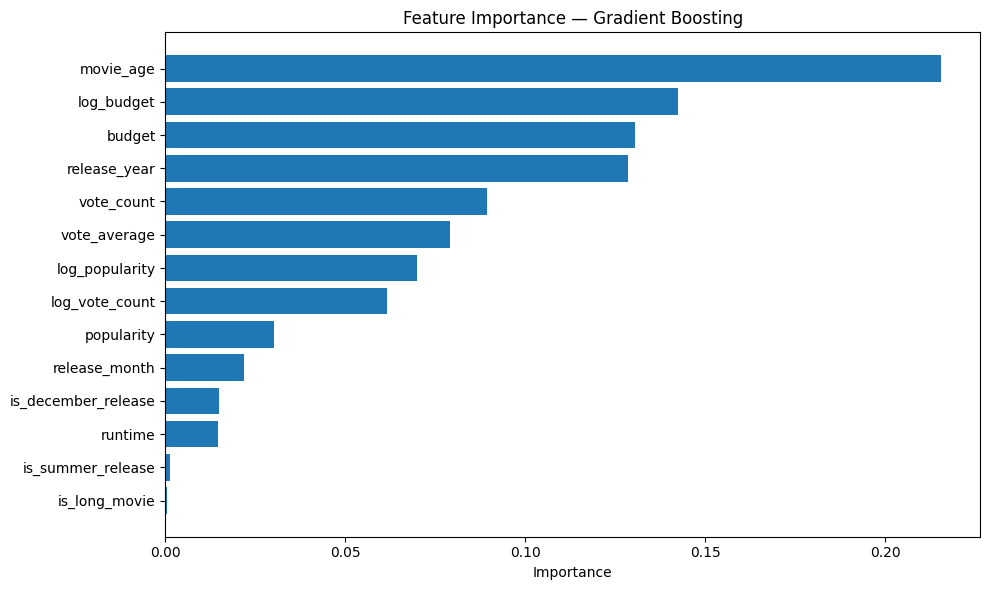

In [16]:
plt.figure(figsize=(10, 6))

plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()

plt.title('Feature Importance — Gradient Boosting')
plt.xlabel('Importance')
plt.tight_layout()

plt.savefig('../data/feature_importance_extended.png', dpi=150)
plt.show()

In [17]:
top_features = importance_df.head(8)['Feature'].tolist()

print("Features selectate:")
print(top_features)

Features selectate:
['movie_age', 'log_budget', 'budget', 'release_year', 'vote_count', 'vote_average', 'log_popularity', 'log_vote_count']


In [19]:
# Resetăm lista de rezultate ca să nu se dubleze la rulări repetate
results = []

results.append(
    evaluate_model(
        basic_features,
        GradientBoostingRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting — features de bază'
    )
)

results.append(
    evaluate_model(
        extended_features,
        GradientBoostingRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting — features extinse'
    )
)

results.append(
    evaluate_model(
        top_features,
        GradientBoostingRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting — top features'
    )
)

results_df = pd.DataFrame(results)

print(results_df.sort_values('R2', ascending=False).to_string(index=False))

                               Model  Nr. features       R2     RMSE
    Gradient Boosting — top features             8 0.516112 5.681816
Gradient Boosting — features extinse            14 0.510800 5.712918
Gradient Boosting — features de bază             7 0.492445 5.819103


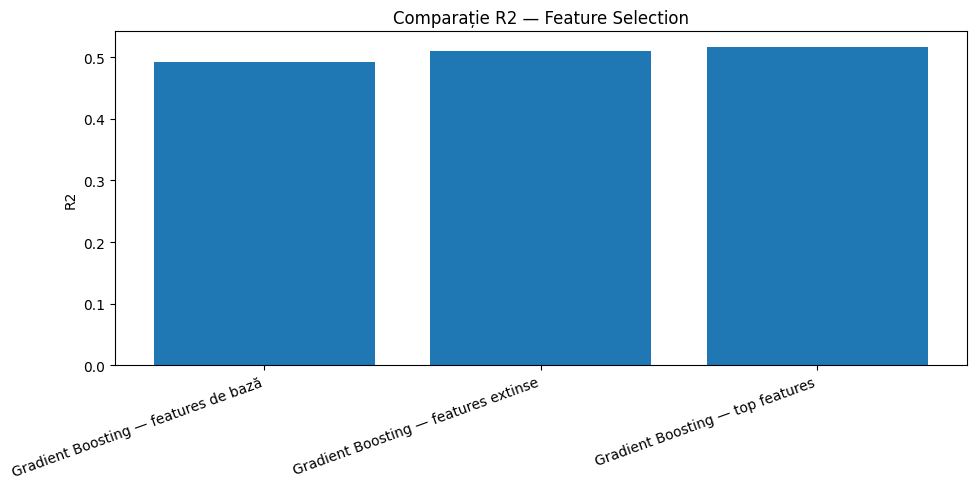

In [20]:
plt.figure(figsize=(10, 5))

plt.bar(results_df['Model'], results_df['R2'])

plt.title('Comparație R2 — Feature Selection')
plt.ylabel('R2')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()

plt.savefig('../data/feature_selection_comparison.png', dpi=150)
plt.show()

## Concluzie

Am testat trei variante de seturi de variabile independente: setul de bază, setul extins cu variabile construite prin feature engineering și un set redus selectat pe baza importanței variabilelor.

Scopul a fost să verific dacă modelul poate obține performanțe mai bune printr-o alegere mai bună a variabilelor independente.

Dacă modelul extins obține un R2 mai mare și un RMSE mai mic, atunci păstrez variabilele noi în modelul final. Dacă modelul cu top features are performanță apropiată, acesta poate fi preferat deoarece este mai simplu și mai ușor de interpretat.

## 6.4. Hiperparametrizare Gradient Boosting

După alegerea setului de variabile, am optimizat hiperparametrii modelului Gradient Boosting folosind GridSearchCV. Scopul este să verific dacă modelul poate generaliza mai bine pe date noi.

In [21]:
from sklearn.model_selection import GridSearchCV

In [23]:
# Folosim top_features.

X = df[top_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

gb_base = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [1, 3, 5],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Cei mai buni hiperparametri:")
print(grid_search.best_params_)

print(f"Cel mai bun R2 mediu în cross-validation: {grid_search.best_score_:.4f}")

Cei mai buni hiperparametri:
{'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 1, 'n_estimators': 300, 'subsample': 0.8}
Cel mai bun R2 mediu în cross-validation: 0.4252


In [24]:
best_gb = grid_search.best_estimator_

y_pred_best = best_gb.predict(X_test)

r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print("Gradient Boosting optimizat:")
print(f"R2 pe test: {r2_best:.4f}")
print(f"RMSE pe test: {rmse_best:.4f}")

Gradient Boosting optimizat:
R2 pe test: 0.5167
RMSE pe test: 5.6785


In [28]:
# Model Gradient Boosting inițial, pe aceleași features folosite la optimizare
gb_initial = GradientBoostingRegressor(n_estimators=100, random_state=42)

gb_initial.fit(X_train, y_train)
y_pred_initial = gb_initial.predict(X_test)

r2_initial = r2_score(y_test, y_pred_initial)
rmse_initial = np.sqrt(mean_squared_error(y_test, y_pred_initial))

# Model Gradient Boosting optimizat
best_gb = grid_search.best_estimator_

y_pred_best = best_gb.predict(X_test)

r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

comparison_tuning = pd.DataFrame({
    'Model': [
        'Gradient Boosting inițial',
        'Gradient Boosting optimizat'
    ],
    'R2': [
        r2_initial,
        r2_best
    ],
    'RMSE': [
        rmse_initial,
        rmse_best
    ]
})

print(comparison_tuning.to_string(index=False))

                      Model       R2     RMSE
  Gradient Boosting inițial 0.516112 5.681816
Gradient Boosting optimizat 0.516683 5.678464


### Interpretare hiperparametrizare

În această etapă am aplicat hiperparametrizarea modelului Gradient Boosting folosind GridSearchCV, cu scopul de a verifica dacă ajustarea hiperparametrilor poate îmbunătăți performanța predictivă.

Rezultatele arată că modelul optimizat obține un R2 de 0.5167, ușor mai mare decât modelul inițial, care avea un R2 de 0.5161. De asemenea, RMSE scade de la 5.6818 la 5.6785.

Diferența dintre cele două modele este redusă, ceea ce sugerează că modelul inițial era deja destul de bine calibrat. Totuși, deoarece modelul optimizat are atât R2 mai mare, cât și RMSE mai mic pe setul de test, acesta este ales ca model final.

Prin urmare, modelul final al proiectului este Gradient Boosting optimizat.

In [29]:
if r2_best > r2_initial:
    final_model = best_gb
    final_model_name = "Gradient Boosting optimizat"
else:
    final_model = gb_initial
    final_model_name = "Gradient Boosting inițial"

print(f"Model final ales: {final_model_name}")

Model final ales: Gradient Boosting optimizat
